In [1]:
import asyncio
from pyproj import Transformer
import numpy as np
import json
import leafmap

In [2]:
from samgeo import raster_to_vector
import uuid
import json
from typing import Dict, Any
import sys
import os
from pyproj import Transformer
from samgeo import tms_to_geotiff
import math
import itertools
# Model Settings
DEFAULT_MODEL_TYPE = "sam2-hiera-large"

MAX_TILES_LIMIT = 1000

In [3]:

from samgeo.text_sam import LangSAM
sam = LangSAM(model_type=DEFAULT_MODEL_TYPE)

final text_encoder_type: bert-base-uncased


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [4]:

def transform_coordinates(geojson_data):
    transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    """Transform coordinates from EPSG:3857 to EPSG:4326"""
    if not geojson_data or 'features' not in geojson_data:
        return geojson_data

    for feature in geojson_data['features']:
        if 'geometry' not in feature:
            continue

        geometry = feature['geometry']
        if geometry['type'] == 'Polygon':
            for i, ring in enumerate(geometry['coordinates']):
                transformed_coords = []
                for x, y in ring:
                    lon, lat = transformer.transform(x, y)
                    transformed_coords.append([lon, lat])
                geometry['coordinates'][i] = transformed_coords
        elif geometry['type'] == 'MultiPolygon':
            for i, polygon in enumerate(geometry['coordinates']):
                for j, ring in enumerate(polygon):
                    transformed_coords = []
                    for x, y in ring:
                        lon, lat = transformer.transform(x, y)
                        transformed_coords.append([lon, lat])
                    geometry['coordinates'][i][j] = transformed_coords

    geojson_data['crs'] = {
        "type": "name",
        "properties": {
            "name": "urn:ogc:def:crs:EPSG::4326"
        }
    }
    return geojson_data

def download_satellite_image(image_name, bounding_box, zoom_level):
    """Download satellite image for the given bounding box and zoom level"""
    tms_to_geotiff(
        output=image_name,
        bbox=bounding_box,
        zoom=zoom_level,
        source="Satellite",
        overwrite=True
    )


In [5]:

request_id = str(uuid.uuid4())
input_image = f"satellite_{request_id}.tif"
output_image = f"segment_{request_id}.tif"
output_geojson = f"segment_{request_id}.geojson"

async def make_prediction(
        bounding_box: list,
        text_prompt: str,
        box_threshold: float = 0.3,
        text_threshold: float = 0.3,
        zoom_level: int = 20
    ) -> Dict[str, Any]:

        # Generate unique filenames
        print(f"[Info] Generated request ID: {request_id}")
        input_image = f"satellite_{request_id}.tif"
        output_image = f"segment_{request_id}.tif"
        output_geojson = f"segment_{request_id}.geojson"

        try:
            # Download satellite imagery
            print("\n[Download] Downloading satellite imagery...")
            try:
                download_satellite_image(
                    input_image,
                    bounding_box,
                    zoom_level
                )
                print("[Download] Satellite imagery downloaded successfully")
            except Exception as e:
                print(f"[Error] Failed to download satellite imagery: {str(e)}")
                raise Exception("Failed to download satellite imagery: `{str(e)}`")

            # Run prediction
            print("\n[Predict] Running SAM prediction...")
            try:
                sam.predict(
                    input_image,
                    text_prompt,
                    box_threshold,
                    text_threshold
                )
                print("[Predict] SAM prediction completed successfully")
            except Exception:
                print("[Error] Failed to run SAM prediction")
                raise Exception("Failed to run SAM prediction: `{str(e)}`")

            # Generate visualization
            print("\n[Info] Generating visualization...")
            try:
                sam.show_anns(
                    cmap="Greys_r",
                    add_boxes=False,
                    alpha=1,
                    title=f"Automatic Segmentation of {text_prompt}",
                    blend=False,
                    output=output_image,
                )
                print("[Info] Visualization generated successfully")
            except Exception:
                print("[Error] Failed to generate visualization")
                raise

            # Convert to GeoJSON
            try:
                raster_to_vector(output_image, output_geojson, None)
                print("[Convert] GeoJSON converted successfully")
            except Exception as e:
                print(f"[Error] Failed to convert to GeoJSON: No vector data found in the image")
                raise Exception("No vector data found in the image")

            # Read and process GeoJSON
            try:
                with open(output_geojson, 'r') as f:
                    geojson_content = json.load(f)
                print(f"[Process] Loaded GeoJSON with {len(geojson_content.get('features', []))} features")

                transformed_geojson = transform_coordinates(geojson_content)
                geojson_count = len(transformed_geojson.get('features', []))
                print(f"[Process] Transformed {geojson_count} features to WGS84")

                return {
                    "errors": None,
                    "version": "1.0",
                    "predictions": f"Successfully found {geojson_count} features",
                    "geojson": transformed_geojson
                }

            except Exception as e:
                print(f"[Error] Failed to process GeoJSON: {str(e)}")
                raise

        except Exception as e:
            print(f"\n[Error] Exception occurred: {str(e)}")
            return {"error": str(e)}



In [6]:
def get_bounding_box(points, buffer_meters=10, lat_first=True):
    """
    Calculate bounding box from points with buffer in meters
    Args:
        points: List of points, either [lat, lon] or [lon, lat]
        buffer_meters: Buffer distance in meters
        lat_first: True if points are [lat, lon], False if [lon, lat]
    Returns:
        [west, south, east, north] bounding box
    """
    points = np.array(points)

    to_meters = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    to_latlon = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    # Handle coordinate order
    if lat_first:
        # Convert [lat, lon] to [lon, lat] for transformation
        points_meters = np.array([to_meters.transform(lon, lat) for lat, lon in points])
    else:
        # Points already in [lon, lat] order
        points_meters = np.array([to_meters.transform(x, y) for x, y in points])

    # Calculate bounds with buffer
    min_x = np.min(points_meters[:, 0]) - buffer_meters
    max_x = np.max(points_meters[:, 0]) + buffer_meters
    min_y = np.min(points_meters[:, 1]) - buffer_meters
    max_y = np.max(points_meters[:, 1]) + buffer_meters

    # Convert back to lat/lon
    west, south = to_latlon.transform(min_x, min_y)
    east, north = to_latlon.transform(max_x, max_y)

    return [west, south, east, north]


In [7]:
bbox1 = [
-76.16560917169102,
43.046243663472765,
-76.1636565235279,
43.047411911551116,
]

# 443 n Franklin st ny
pnt1 = [43.05692144640928, -76.15648427005198]
pnt2 = [43.05635088078998, -76.15741548689955]
pnt_443_franklin = [pnt1, pnt2]

# 443 n Franklin st ny
pnt3 = [43.04752217221759, -76.16380968454094]
pnt4 = [43.046196545696866, -76.16543061124729]
pnt_715_w_fayette = [pnt1, pnt2]

# get_bounding_box(pnt_443_franklin, buffer_meters=0, lat_first=True)

In [8]:
zoom_level = 21

# research suggested to use low box_threshold for trees(irregular shape) and high box_threshold for buildings(regular shape)
text_prompts =     {
        'value':'building',
        'box_threshold':0.25,
        'text_threshold':0.25,

    }


bbox = get_bounding_box(pnt_443_franklin, buffer_meters=0, lat_first=True)


[Info] Generated request ID: 22b00f05-3125-4b7e-8291-d21c29c55868

[Download] Downloading satellite imagery...
Downloaded image 01/35
Downloaded image 02/35
Downloaded image 03/35
Downloaded image 04/35
Downloaded image 05/35
Downloaded image 06/35
Downloaded image 07/35
Downloaded image 08/35
Downloaded image 09/35
Downloaded image 10/35
Downloaded image 11/35
Downloaded image 12/35
Downloaded image 13/35
Downloaded image 14/35
Downloaded image 15/35
Downloaded image 16/35
Downloaded image 17/35
Downloaded image 18/35
Downloaded image 19/35
Downloaded image 20/35
Downloaded image 21/35
Downloaded image 22/35
Downloaded image 23/35
Downloaded image 24/35
Downloaded image 25/35
Downloaded image 26/35
Downloaded image 27/35
Downloaded image 28/35
Downloaded image 29/35
Downloaded image 30/35
Downloaded image 31/35
Downloaded image 32/35
Downloaded image 33/35
Downloaded image 34/35
Downloaded image 35/35
Saving GeoTIFF. Please wait...
Image saved to satellite_22b00f05-3125-4b7e-8291-d21c

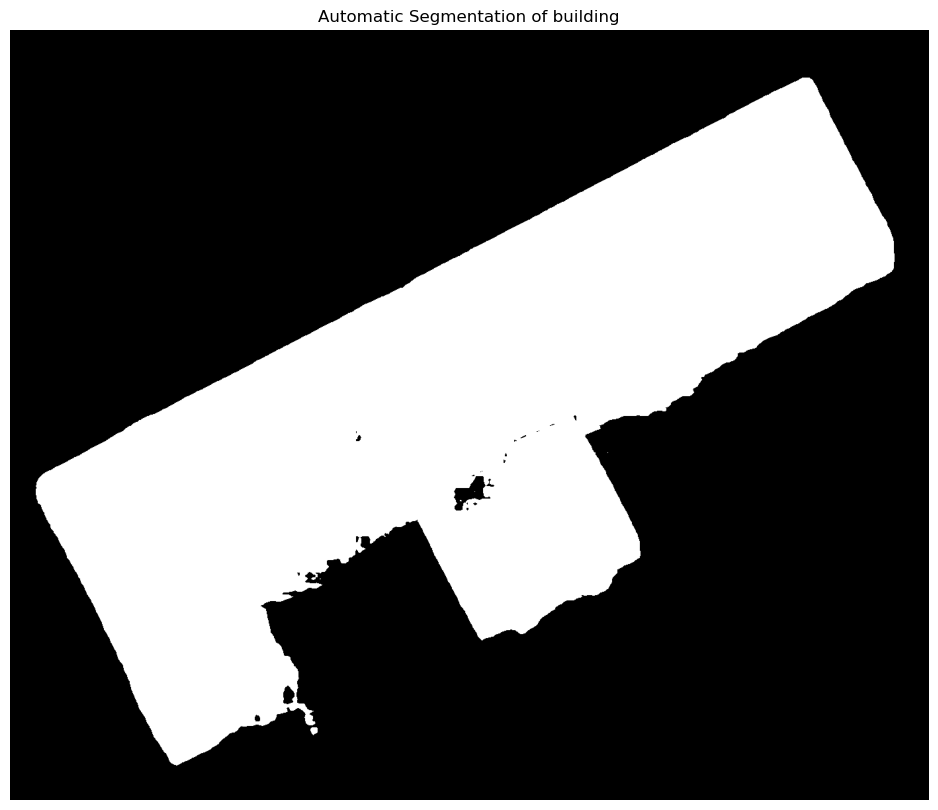

In [9]:
async def run_prediction():
    result = await make_prediction(
        bounding_box=bbox,
        text_prompt= text_prompts['value'],
        box_threshold= text_prompts['box_threshold'],
        text_threshold= text_prompts['text_threshold'],
        zoom_level= zoom_level,
    )
    return result

result = await run_prediction()

In [10]:
center_lat = (bbox[1] + bbox[3]) / 2
center_lon = (bbox[0] + bbox[2]) / 2
m = leafmap.Map(center=[center_lon, center_lat], zoom=19, height="300px")
m.add_basemap("SATELLITE")
m.layers[-1].visible = False
m.add_raster(input_image, layer_name="Image")
m.add_raster(output_image, layer_name="Image")
# add geojson to map
m.add_geojson(result.get('geojson'), layer_name="Predictions", style={"color": "yellow", "fillOpacity": 0.2})
m


Map(center=[43.056636, -76.1569495], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…